Loading recording: VP_01 / game_2026-03-24_09-00-13
Path: /Users/paul/Coding_Projects/Master/Dataprocessing/playagain_pipeline/data/game_recordings/VP_01/game_2026-03-24_09-00-13/recording.csv
Loaded 285,264 samples (142.6 s)
Extracted 10 trials.
Activity source: GroundTruthActive
  - Tripod (6.06s)
  - Fist (6.06s)
  - Fist (6.07s)
  ...
Total analyzed samples: 122958
Estimated duration: 120.00 s


/Users/paul/Coding_Projects/Master/Dataprocessing/playagain_pipeline/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Sample-level Accuracy: 81.86%
Weighted F1 Score:     0.897
Weighted Recall:       0.819

Classification Report:
              precision    recall  f1-score   support

        Fist       1.00      0.97      0.98     36414
       Pinch       1.00      0.80      0.89     48438
        Rest       0.00      0.00      0.00         0
      Tripod       1.00      0.71      0.83     38106

    accuracy                           0.82    122958
   macro avg       0.75      0.62      0.67    122958
weighted avg       1.00      0.82      0.90    122958



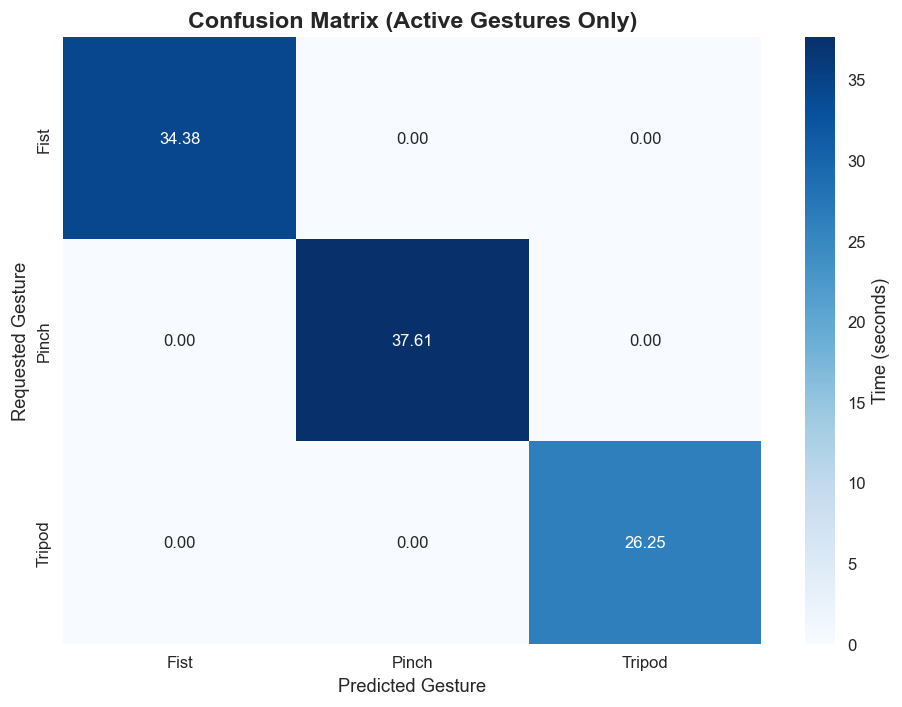

Per-Gesture Performance Metrics:
Gesture  Accuracy  Precision  Recall  F1-Score  Samples  Duration (s)
   Fist       1.0        1.0     1.0       1.0    35226     34.379214
  Pinch       1.0        1.0     1.0       1.0    38538     37.611598
 Tripod       1.0        1.0     1.0       1.0    26892     26.245552


/var/folders/67/cw1hn_wx057c8n3ptk_myyg40000gn/T/ipykernel_65655/3669804620.py:275: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=acc_df, x='Gesture', y='Trial Accuracy', ax=ax, palette='Set2')


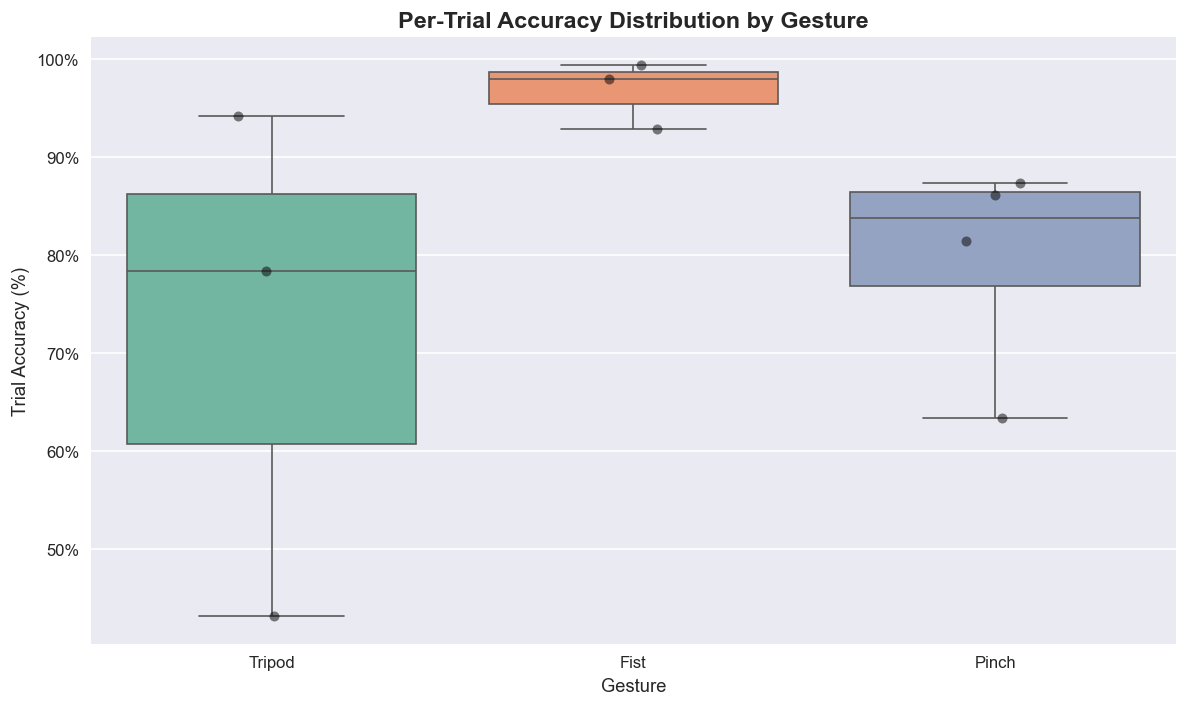

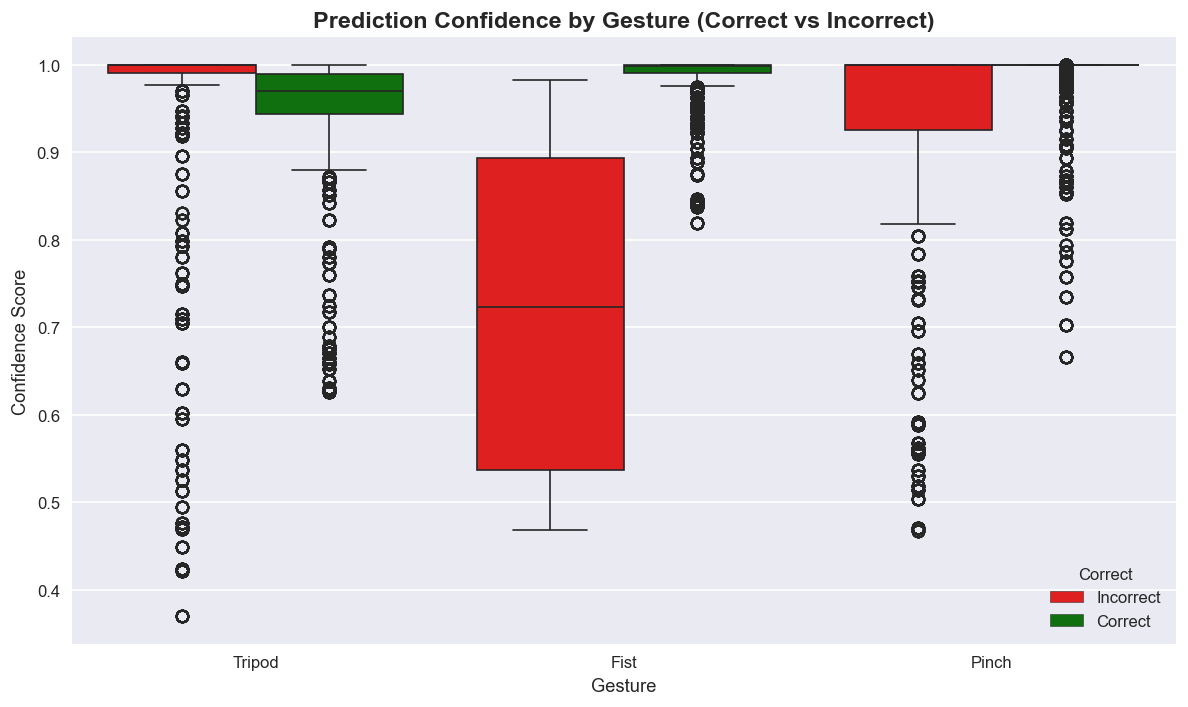

/var/folders/67/cw1hn_wx057c8n3ptk_myyg40000gn/T/ipykernel_65655/3669804620.py:329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Gesture', y='Accuracy', ax=ax, palette='viridis')
/var/folders/67/cw1hn_wx057c8n3ptk_myyg40000gn/T/ipykernel_65655/3669804620.py:336: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Gesture', y='Recall', ax=ax, palette='plasma')
/var/folders/67/cw1hn_wx057c8n3ptk_myyg40000gn/T/ipykernel_65655/3669804620.py:343: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='

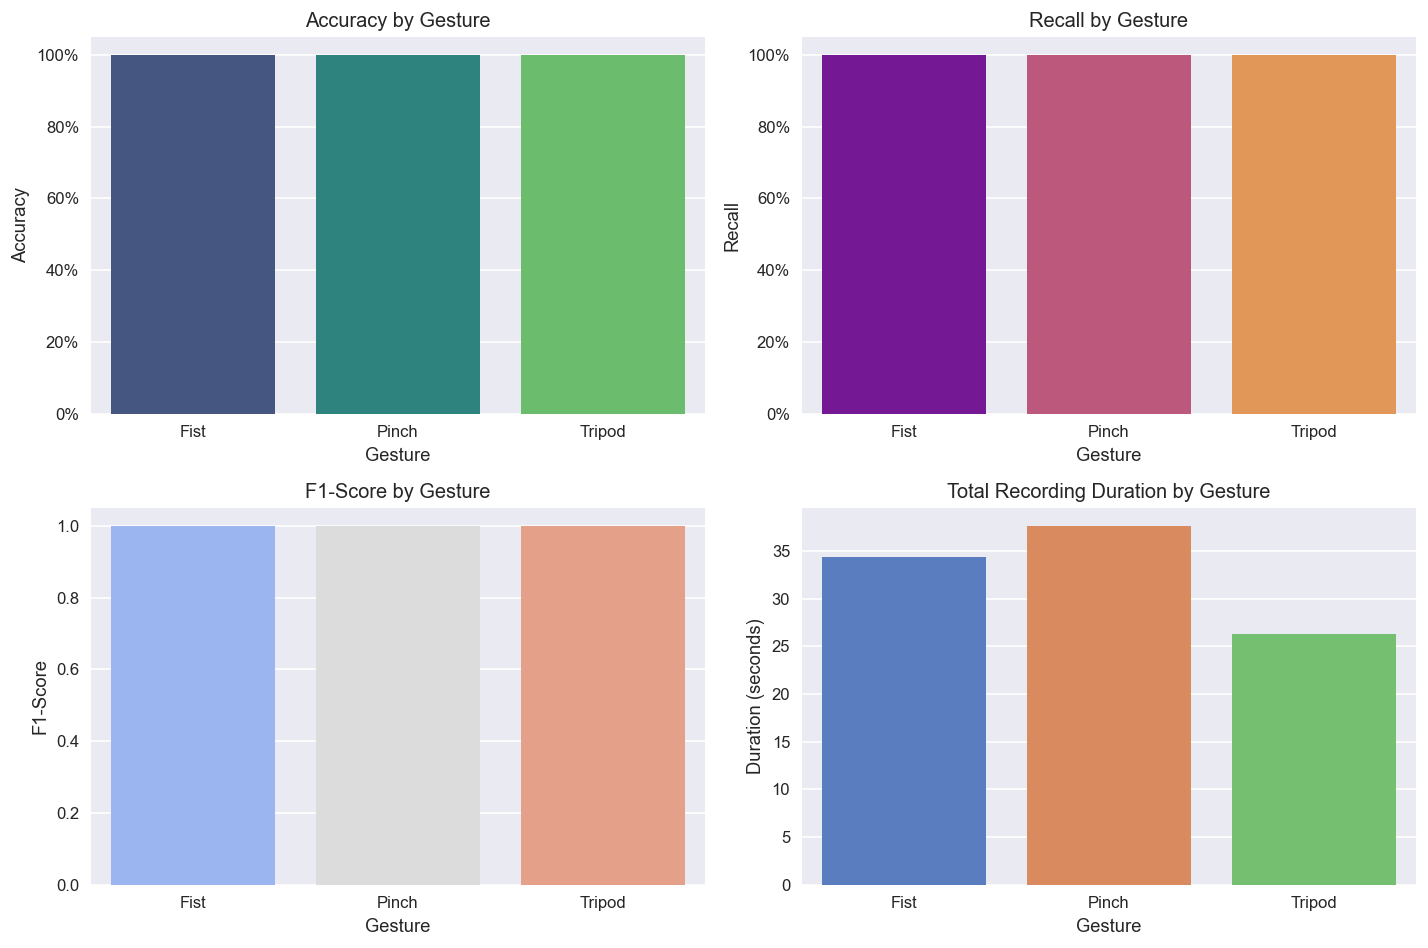

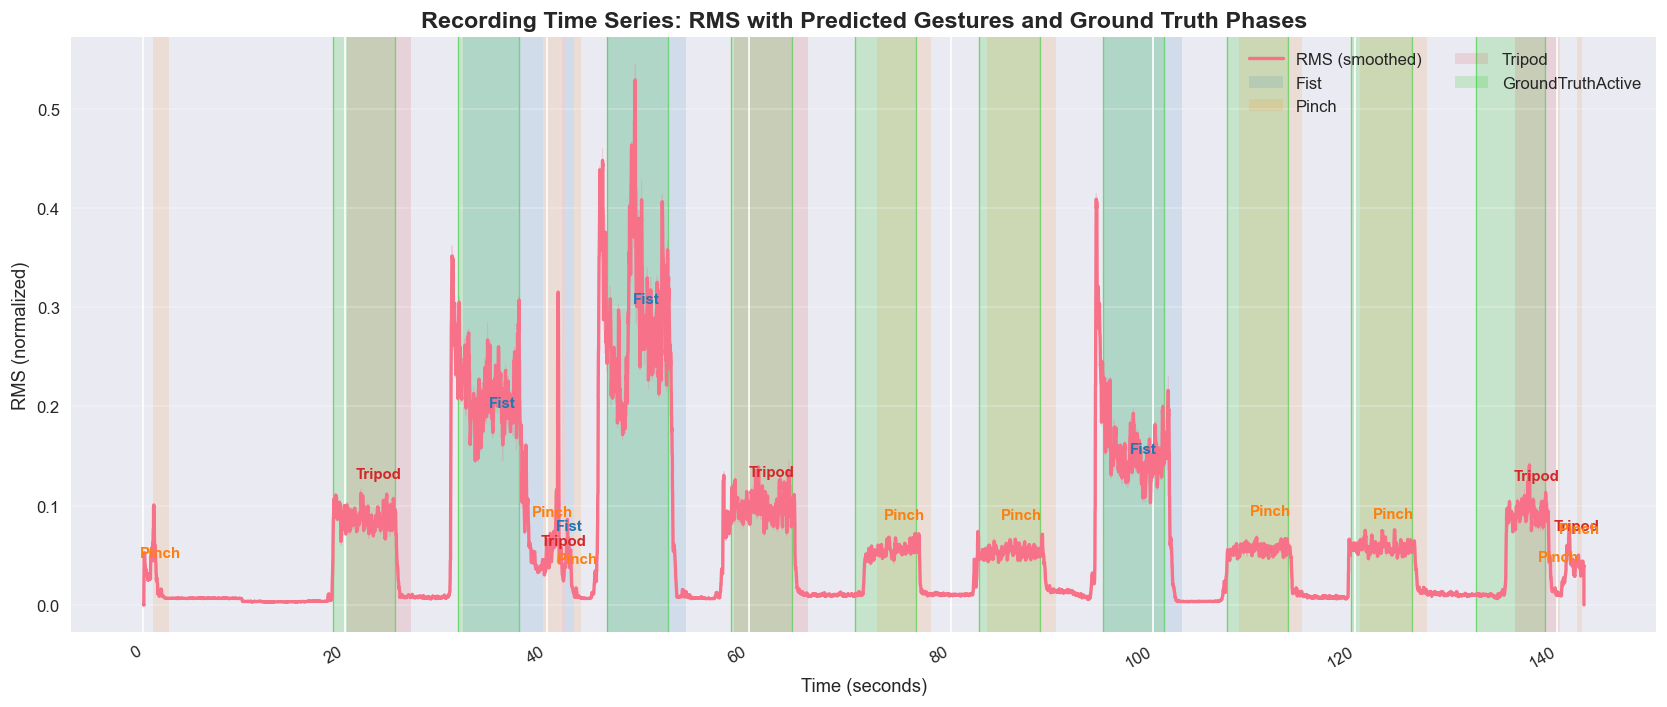

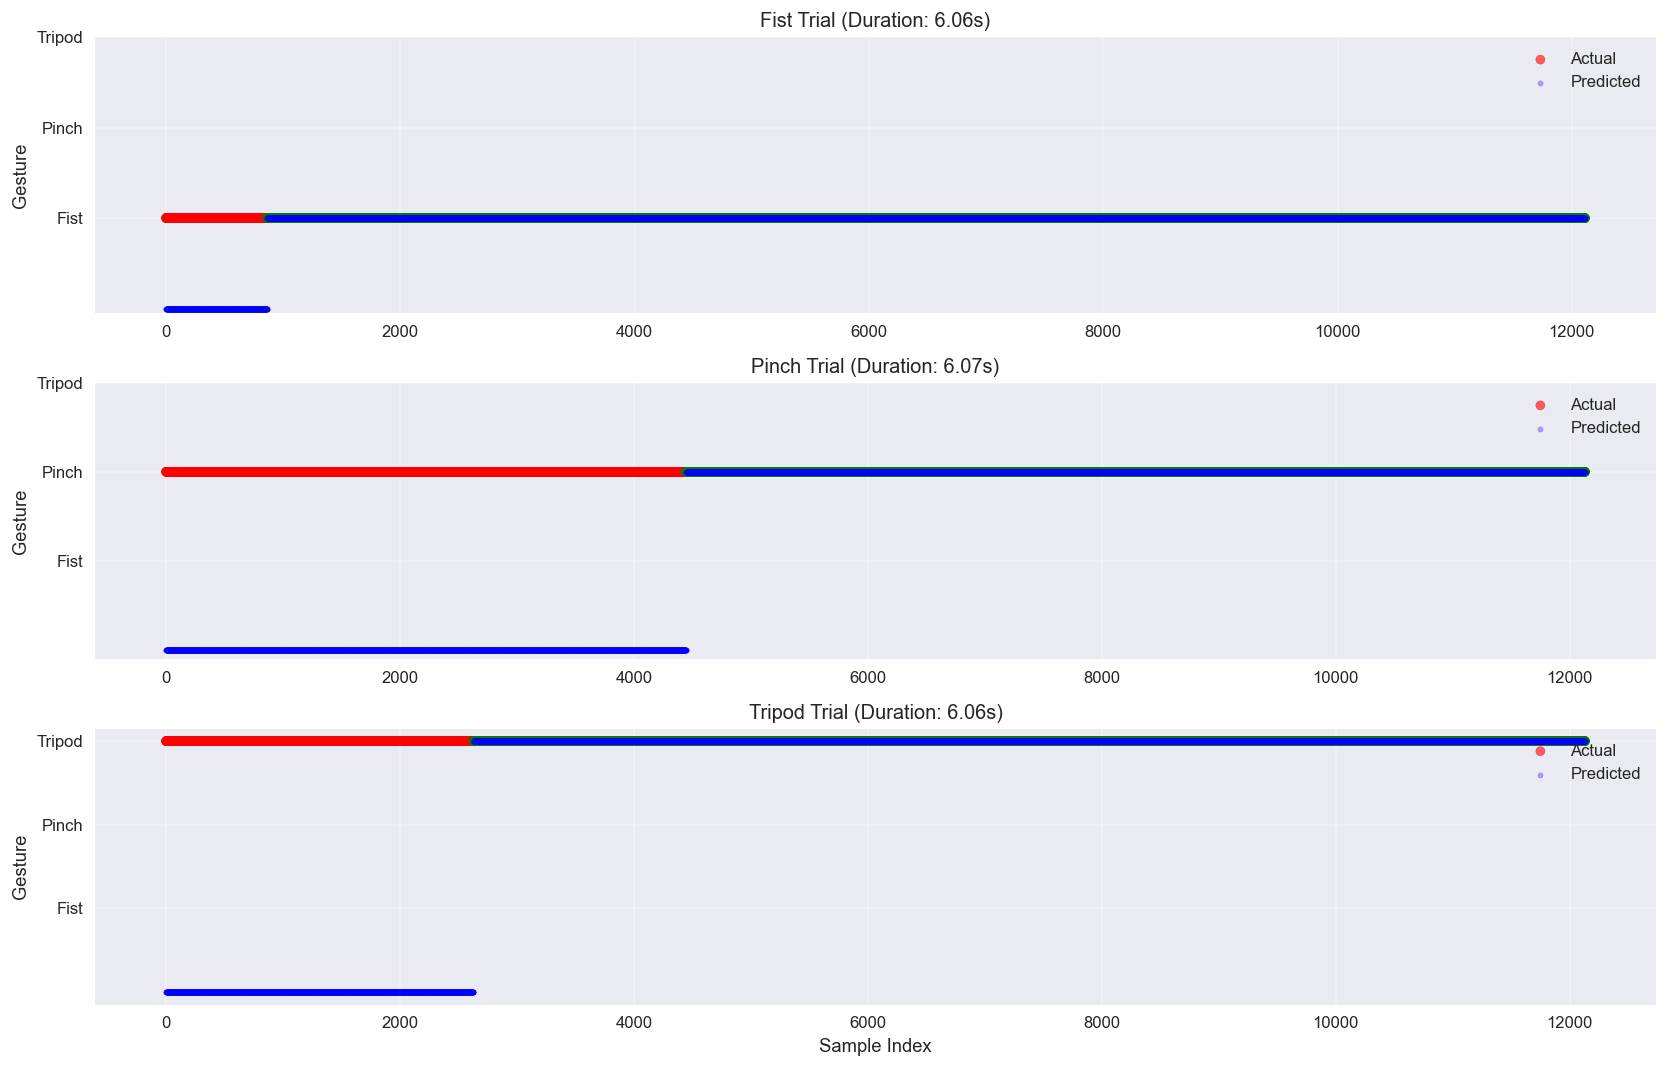

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score
from pathlib import Path
import json, warnings

#warnings.filterwarnings("ignore", category=FutureWarning)

# ── Style ──────────────────────────────────────────────────────────────────────
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

# ── Paths & settings ──────────────────────────────────────────────────────────
current_nb_dir = Path.cwd()
DATA_ROOT = (current_nb_dir.parent / "data" / "game_recordings").resolve()
CANONICAL_LABELS = ["Rest", "Fist", "Pinch", "Tripod"]  # display order

# ── Select specific recording to analyse ──────────────────────────────────────
# Set the subject and session folder name (without paths)
TARGET_SUBJECT = "VP_01"
TARGET_SESSION = "game_2026-03-24_09-00-13"

# Construct paths directly
session_dir = DATA_ROOT / TARGET_SUBJECT / TARGET_SESSION
csv_path = session_dir / "recording.csv"
if not csv_path.exists():
    # Try legacy path if new structure not found
    csv_path = session_dir.with_suffix(".csv")

if not csv_path.exists():
    raise FileNotFoundError(f"Could not find recording at: {csv_path}")

print(f"Loading recording: {TARGET_SUBJECT} / {TARGET_SESSION}")
print(f"Path: {csv_path}")

# Label normalisation map
_LABEL_MAP = {
    "rest": "Rest", "relax": "Rest", "none": "Rest",
    "fist": "Fist", "pinch": "Pinch", "tripod": "Tripod",
}


def normalise_label(label: str) -> str:
    """Map any prediction / ground-truth string to a canonical label."""
    return _LABEL_MAP.get(str(label).strip().lower(), str(label).strip().title())


def get_activity_mask(df: pd.DataFrame) -> tuple[np.ndarray, str]:
    """Infer binary active/inactive samples across old and new recording schemas."""
    for col in ("GroundTruthActive", "GroundTruth", "GestureActive", "CameraBlocking"):
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors="coerce").fillna(0.0).to_numpy(float)
            return vals > 0.5, col
    return np.zeros(len(df), dtype=bool), "none"


## 1 — Load recording & extract trials
# Load DataFrame
df = pd.read_csv(csv_path)
n_samples = len(df)
duration = df["Timestamp"].iloc[-1] - df["Timestamp"].iloc[0]
print(f"Loaded {n_samples:,} samples ({duration:.1f} s)")


def extract_trials_from_df(df: pd.DataFrame) -> list[dict]:
    """Return trial dicts from contiguous active spans and requested labels."""
    if "RequestedGesture" not in df.columns:
        return []

    requested_series = df["RequestedGesture"].apply(normalise_label)
    active_mask, active_source = get_activity_mask(df)

    trials = []
    starts = np.flatnonzero(active_mask & ~np.roll(active_mask, 1))
    if active_mask.size:
        starts = starts[starts != 0] if not active_mask[0] else np.concatenate(([0], starts[starts != 0]))
    ends = np.flatnonzero(active_mask & ~np.roll(active_mask, -1))
    if active_mask.size and active_mask[-1] and (len(ends) == 0 or ends[-1] != len(active_mask) - 1):
        ends = np.concatenate((ends, [len(active_mask) - 1]))

    for s, e in zip(starts.tolist(), ends.tolist()):
        trial_data = df.iloc[s:e + 1].copy()
        req_mode = requested_series.iloc[s:e + 1]
        req_mode = req_mode[req_mode != "Rest"]
        if req_mode.empty:
            continue
        requested_label = req_mode.mode().iloc[0]
        trials.append({
            "start_idx": s,
            "end_idx": e,
            "t_start": float(df.iloc[s]["Timestamp"]),
            "t_end": float(df.iloc[e]["Timestamp"]),
            "requested": requested_label,
            "data": trial_data,
            "activity_source": active_source,
        })
    return trials


trials = extract_trials_from_df(df)
print(f"Extracted {len(trials)} trials.")
if len(df) > 0:
    _, activity_source = get_activity_mask(df)
    print(f"Activity source: {activity_source}")
for t in trials[:3]:
    print(f"  - {t['requested']} ({t['t_end'] - t['t_start']:.2f}s)")
if len(trials) > 3: print("  ...")

## 2 — Performance Metrics (Sample-level)

# Compute
# accuracy, F1 - score, and recall
# based
# on
# sample
# duration(seconds).
# Gather all samples from the trials
y_true = []
y_pred = []
timestamps = []

for t in trials:
    d = t["data"]
    # Get ground truth from the trial metadata (requested gesture)
    # We repeat it for the length of the trial
    # Note: If 'GroundTruthActive' implies we should trust 'RequestedGesture' over the whole period
    # valid samples are those in the trial.

    # Current trial requested label
    req = t["requested"]

    # Predicted labels
    preds = d["PredictedGesture"].apply(normalise_label)

    y_true.extend([req] * len(preds))
    y_pred.extend(preds.tolist())
    timestamps.extend(d["Timestamp"].tolist())

# Convert to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate duration per sample
# (We assume relatively constant sampling rate, or we can just sum up durations)
# An estimate of time per sample:
if len(timestamps) > 1:
    avg_dt = (timestamps[-1] - timestamps[0]) / (len(timestamps) - 1)
else:
    avg_dt = 1 / 60.0  # fallback

print(f"Total analyzed samples: {len(y_true)}")
print(f"Estimated duration: {len(y_true) * avg_dt:.2f} s")

active_labels = []
y_true_active = np.array([])
y_pred_active = np.array([])

if len(y_true) == 0:
    print("No valid active trials found; skipping metrics and gesture-level plots.")
else:
    # Compute Metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")

    print(f"Sample-level Accuracy: {accuracy:.2%}")
    print(f"Weighted F1 Score:     {f1:.3f}")
    print(f"Weighted Recall:       {recall:.3f}")

    print("\nClassification Report:")
    report_labels = sorted(list(set(y_true) | set(y_pred)))
    if report_labels:
        print(classification_report(y_true, y_pred, labels=report_labels, zero_division=0))
    else:
        print("No labels available for classification report.")

## 3 — Visualization: Confusion Matrix (Active Gestures Only - Seconds)

# Exclude
# "Rest"
# since
# it
# 's not a requested gesture.
# Filter out Rest labels (only include active gestures)
if len(y_true) > 0:
    active_mask = (y_true != "Rest") & (y_pred != "Rest")
    y_true_active = y_true[active_mask]
    y_pred_active = y_pred[active_mask]

    # Get active gesture labels only
    active_labels = sorted(list(set(y_true_active) | set(y_pred_active)))

if len(active_labels) == 0:
    print("No active gesture samples available for confusion matrix.")
else:
    cm_counts = confusion_matrix(y_true_active, y_pred_active, labels=active_labels)

    # Convert counts to seconds
    cm_seconds = cm_counts * avg_dt

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_seconds, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=active_labels, yticklabels=active_labels, ax=ax,
                cbar_kws={'label': 'Time (seconds)'})
    ax.set_title("Confusion Matrix (Active Gestures Only)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Predicted Gesture")
    ax.set_ylabel("Requested Gesture")
    plt.tight_layout()
    plt.show()

## 4 — Per-Gesture Performance Analysis
# Compute per-gesture metrics
from sklearn.metrics import precision_score, recall_score, f1_score

gesture_metrics = []
for gesture in active_labels:
    mask = y_true_active == gesture
    y_true_gesture = y_true_active[mask]
    y_pred_gesture = y_pred_active[mask]

    accuracy = accuracy_score(y_true_gesture, y_pred_gesture)
    precision = precision_score(y_true_active, y_pred_active, labels=[gesture], average='weighted', zero_division=0)
    recall_val = recall_score(y_true_gesture, y_pred_gesture, average='weighted', zero_division=0)
    f1_val = f1_score(y_true_gesture, y_pred_gesture, average='weighted', zero_division=0)
    num_samples = len(y_true_gesture)
    duration_s = num_samples * avg_dt

    gesture_metrics.append({
        'Gesture': gesture,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall_val,
        'F1-Score': f1_val,
        'Samples': num_samples,
        'Duration (s)': duration_s
    })

metrics_df = pd.DataFrame(gesture_metrics)
print("Per-Gesture Performance Metrics:")
if metrics_df.empty:
    print("No per-gesture metrics available.")
else:
    print(metrics_df.to_string(index=False))

## 5 — Accuracy Boxplot by Gesture
# Create per-sample accuracy data for each gesture
accuracy_data = []
for t in trials:
    d = t["data"]
    req = t["requested"]
    preds = d["PredictedGesture"].apply(normalise_label)

    # Calculate accuracy for this trial
    trial_correct = (np.array([req] * len(preds)) == np.array(preds))
    trial_accuracy = trial_correct.mean()

    accuracy_data.append({
        'Gesture': req,
        'Trial Accuracy': trial_accuracy,
        'Duration (s)': (d["Timestamp"].iloc[-1] - d["Timestamp"].iloc[0])
    })

acc_df = pd.DataFrame(accuracy_data)

if acc_df.empty:
    print("No trials available for per-trial accuracy boxplot.")
else:
    # Boxplot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=acc_df, x='Gesture', y='Trial Accuracy', ax=ax, palette='Set2')
    sns.stripplot(data=acc_df, x='Gesture', y='Trial Accuracy', ax=ax, color='black', alpha=0.5, size=6)
    ax.set_title("Per-Trial Accuracy Distribution by Gesture", fontsize=14, fontweight='bold')
    ax.set_ylabel("Trial Accuracy (%)")
    ax.set_xlabel("Gesture")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    plt.tight_layout()
    plt.show()

## 6 — Prediction Confidence Analysis
# Extract confidence values (if available in the CSV)
confidence_col = "PredictionConfidence" if "PredictionConfidence" in df.columns else ("Confidence" if "Confidence" in df.columns else None)
if confidence_col is not None:
    confidence_data = []

    for t in trials:
        d = t["data"]
        req = t["requested"]
        preds = d["PredictedGesture"].apply(normalise_label).values
        confs = d[confidence_col].values

        # Separate correct vs incorrect predictions
        is_correct = (preds == req)

        for pred, conf, correct in zip(preds, confs, is_correct):
            confidence_data.append({
                'Gesture': req,
                'Confidence': conf,
                'Correct': 'Correct' if correct else 'Incorrect'
            })

    conf_df = pd.DataFrame(confidence_data)

    if conf_df.empty:
        print("No confidence samples available for confidence analysis.")
    else:
        # Boxplot
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.boxplot(data=conf_df, x='Gesture', y='Confidence', hue='Correct', ax=ax,
                    palette={'Correct': 'green', 'Incorrect': 'red'})
        ax.set_title("Prediction Confidence by Gesture (Correct vs Incorrect)", fontsize=14, fontweight='bold')
        ax.set_ylabel("Confidence Score")
        ax.set_xlabel("Gesture")
        plt.tight_layout()
        plt.show()

## 7 — Performance Summary Bar Chart
if metrics_df.empty:
    print("Skipping summary bar charts (no gesture metrics available).")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Accuracy by gesture
    ax = axes[0, 0]
    sns.barplot(data=metrics_df, x='Gesture', y='Accuracy', ax=ax, palette='viridis')
    ax.set_title("Accuracy by Gesture")
    ax.set_ylabel("Accuracy")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    # Recall by gesture
    ax = axes[0, 1]
    sns.barplot(data=metrics_df, x='Gesture', y='Recall', ax=ax, palette='plasma')
    ax.set_title("Recall by Gesture")
    ax.set_ylabel("Recall")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    # F1-Score by gesture
    ax = axes[1, 0]
    sns.barplot(data=metrics_df, x='Gesture', y='F1-Score', ax=ax, palette='coolwarm')
    ax.set_title("F1-Score by Gesture")
    ax.set_ylabel("F1-Score")

    # Duration by gesture
    ax = axes[1, 1]
    sns.barplot(data=metrics_df, x='Gesture', y='Duration (s)', ax=ax, palette='muted')
    ax.set_title("Total Recording Duration by Gesture")
    ax.set_ylabel("Duration (seconds)")

    plt.tight_layout()
    plt.show()

## 8 — Time Series Predictions with Recording Phases
# Full recording time series with RMS, predictions, and ground truth phases
# Calculate RMS energy across all channels for visualization

from scipy.signal import butter, filtfilt

fs = 2000
low = 20
high = 450
b, a = butter(4, [low, high], btype='band', fs=fs)

emg_cols = [c for c in df.columns if c.startswith('EMG_')]
filtered_emg = np.zeros_like(df[emg_cols].values)
for i, col in enumerate(emg_cols):
    filtered_emg[:, i] = filtfilt(b, a, df[col].values)

# Calculate RMS (rolling window)
rms_window = int(0.1 * fs)  # 100ms
rms_per_channel = pd.DataFrame(filtered_emg).pow(2).rolling(window=rms_window, center=True).mean().pow(0.5)
rms_mean = rms_per_channel.mean(axis=1)

df_plot = df.copy()
df_plot['RMS'] = rms_mean.fillna(0)
df_plot['RMS_smooth'] = df_plot['RMS'].rolling(window=51, center=True, min_periods=1).mean()

# Prepare timestamp
ts = df_plot['Timestamp'].values

# Build gesture segments
gestures = df_plot['PredictedGesture'].apply(normalise_label).fillna('Unknown').astype(str).values
segments = []
start = 0
for i in range(1, len(gestures)):
    if gestures[i] != gestures[i - 1]:
        segments.append((start, i - 1, gestures[start]))
        start = i
segments.append((start, len(gestures) - 1, gestures[start]))

# Choose colors for gestures
unique_gestures = sorted(list(set([seg[2] for seg in segments])))
cmap = plt.get_cmap('tab10')
color_map = {g: cmap(i % cmap.N) for i, g in enumerate(unique_gestures)}

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts, df_plot['RMS'], color='C0', alpha=0.25, label='RMS (raw)', linewidth=0.6)
ax.plot(ts, df_plot['RMS_smooth'], color='C0', label='RMS (smoothed)', linewidth=2)

# Highlight GroundTruthActive segments
if 'GroundTruthActive' in df_plot.columns:
    gtruth = df_plot['GroundTruthActive']
    try:
        gbool = gtruth.astype(bool).values
    except:
        gbool = (gtruth.values == 1) | (gtruth.values == 'True') | (gtruth.values == True)

    # Build ground-truth segments
    gt_segments = []
    s_idx = 0
    for i in range(1, len(gbool)):
        if gbool[i] != gbool[i - 1]:
            gt_segments.append((s_idx, i - 1, gbool[s_idx]))
            s_idx = i
    gt_segments.append((s_idx, len(gbool) - 1, gbool[s_idx]))

    # Draw ground truth active bands
    for s_idx, e_idx, val in gt_segments:
        if not val:
            continue
        t0 = ts[s_idx]
        t1 = ts[e_idx]
        ax.axvspan(t0, t1, color='limegreen', alpha=0.2, linewidth=0, zorder=0)
        ax.axvline(t0, color='limegreen', alpha=0.6, linewidth=0.8, zorder=1)
        ax.axvline(t1, color='limegreen', alpha=0.6, linewidth=0.8, zorder=1)

# Add gesture bands (active gestures only)
for s_idx, e_idx, g in segments:
    if g == 'Rest':
        continue
    t0 = ts[s_idx]
    t1 = ts[e_idx]
    color = color_map.get(g, (0.8, 0.8, 0.8))
    ax.axvspan(t0, t1, color=color, alpha=0.12, linewidth=0, zorder=0.5)

    # Annotate longer segments
    if (e_idx - s_idx + 1) >= 30:
        mid_idx = (s_idx + e_idx) // 2
        tx = ts[mid_idx]
        ty = df_plot['RMS_smooth'].iloc[mid_idx]
        ax.text(tx, ty + 0.06 * (df_plot['RMS_smooth'].max() - df_plot['RMS_smooth'].min()),
                g, color=color_map[g], fontsize=9, fontweight='semibold',
                ha='center', va='bottom', clip_on=True)

# Legend
from matplotlib.patches import Patch

legend_patches = [Patch(facecolor=color_map[g], alpha=0.12, label=g) for g in unique_gestures if g != 'Rest']
legend_patches.append(Patch(facecolor='limegreen', alpha=0.2, label='GroundTruthActive'))
handles = [ax.lines[1]] + legend_patches
ax.legend(handles=handles, loc='upper right', ncol=2, framealpha=0.95)

ax.set_title('Recording Time Series: RMS with Predicted Gestures and Ground Truth Phases', fontsize=14,
             fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('RMS (normalized)')
ax.grid(axis='y', alpha=0.25)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 9 — Time Series Predictions (First Trial of Each Gesture)
# Plot prediction time series for first trial of each gesture
if len(active_labels) == 0:
    print("Skipping first-trial prediction plots (no active gestures available).")
else:
    fig, axes = plt.subplots(len(active_labels), 1, figsize=(14, 3 * len(active_labels)))
    if len(active_labels) == 1:
        axes = [axes]

    for idx, gesture in enumerate(active_labels):
        trial = next((t for t in trials if t['requested'] == gesture), None)
        if trial is None:
            continue

        d = trial['data'].reset_index(drop=True)
        ax = axes[idx]

        # Get predictions and convert to numeric (for coloring)
        preds = d["PredictedGesture"].apply(normalise_label).values
        pred_numeric = np.array([active_labels.index(p) if p in active_labels else -1 for p in preds])

        # Color code: green for correct, red for incorrect
        colors = ['green' if p == gesture else 'red' for p in preds]

        ax.scatter(range(len(preds)), [active_labels.index(gesture)] * len(preds),
                   c=colors, alpha=0.6, s=30, label='Actual')
        ax.scatter(range(len(preds)), pred_numeric, c='blue', alpha=0.3, s=10, label='Predicted')

        ax.set_yticks(range(len(active_labels)))
        ax.set_yticklabels(active_labels)
        ax.set_title(f"{gesture} Trial (Duration: {d['Timestamp'].iloc[-1] - d['Timestamp'].iloc[0]:.2f}s)")
        ax.set_ylabel("Gesture")
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Sample Index")
    plt.tight_layout()
    plt.show()

